In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
df=pd.read_csv('/content/Reviews.tsv',delimiter='\t',quoting=3)

In [3]:
df.describe()

,Liked
count,1000.00000
mean,0.50000
std,0.50025
min,0.00000
25%,0.00000
50%,0.50000
75%,1.00000
max,1.00000


In [4]:
list(df)

['Review', 'Liked']

In [5]:
df.tail(10)

,Review,Liked
990,The refried beans that came with my meal were ...,0
991,Spend your money and time some place else.,0
992,A lady at the table next to us found a live gr...,0
993,the presentation of the food was awful.,0
994,I can't tell you how disappointed I was.,0
995,I think food should have flavor and texture an...,0
996,Appetite instantly gone.,0
997,Overall I was not impressed and would not go b...,0
998,"The whole experience was underwhelming, and I ...",0
999,"Then, as if I hadn't wasted enough of my life ...",0


In [6]:
df.head(30)

,Review,Liked
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1
5,Now I am getting angry and I want my damn pho.,0
6,Honeslty it didn't taste THAT fresh.),0
7,The potatoes were like rubber and you could te...,0
8,The fries were great too.,1
9,A great touch.,1


In [7]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

from nltk.stem import PorterStemmer
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [11]:

v=set(stopwords.words("english"))
import re
bag=[]
for i in range(0,1000):
  review=re.sub('[^a-zA-Z]',' ',df['Review'][i])
  review=review.lower()
  review=review.split()
  lm=PorterStemmer()
  review=[lm.stem(word) for word in review if not word in set(stopwords.words('english'))]
  review=' '.join(review)
  bag.append(review)

In [12]:
print(bag)

['wow love place', 'crust good', 'tasti textur nasti', 'stop late may bank holiday rick steve recommend love', 'select menu great price', 'get angri want damn pho', 'honeslti tast fresh', 'potato like rubber could tell made ahead time kept warmer', 'fri great', 'great touch', 'servic prompt', 'would go back', 'cashier care ever say still end wayyy overpr', 'tri cape cod ravoli chicken cranberri mmmm', 'disgust pretti sure human hair', 'shock sign indic cash', 'highli recommend', 'waitress littl slow servic', 'place worth time let alon vega', 'like', 'burritto blah', 'food amaz', 'servic also cute', 'could care less interior beauti', 'perform', 'right red velvet cake ohhh stuff good', 'never brought salad ask', 'hole wall great mexican street taco friendli staff', 'took hour get food tabl restaur food luke warm sever run around like total overwhelm', 'worst salmon sashimi', 'also combo like burger fri beer decent deal', 'like final blow', 'found place accid could happier', 'seem like go

In [13]:
print(v)

{'down', 'himself', 'where', 'but', 'she', 'about', 'is', 'being', 'in', 'd', 'now', 'such', 've', 'won', 'weren', 'does', "he'll", 'over', 'any', 'above', 'off', "hadn't", 'all', 't', "they'd", 'to', 'at', 'that', "couldn't", "i'm", 'y', 'o', 'am', 'just', "needn't", "isn't", "they've", 'until', 'these', 'from', 'who', "he's", "it'll", 'did', 'doing', 'and', 'do', 'same', 'here', 'shouldn', 'mustn', "didn't", 'ours', 'hasn', "that'll", 'before', 'through', "wasn't", 'further', 'other', 'out', "he'd", 'mightn', 'theirs', 'having', 'll', 'why', 'needn', 'been', 'should', 'it', 'when', 'you', "they'll", "we'll", "she's", "they're", 'with', "you'll", "i've", "shan't", 'a', 'which', 'aren', 'me', "won't", 'below', 'themselves', 'he', 'both', 'an', 'his', 'yours', 'against', 'didn', "you've", 'how', 'if', 're', 'had', 'don', 'be', "mustn't", "doesn't", 'couldn', "weren't", 'him', 'were', 'again', 'into', 'few', 'too', 'under', "you'd", 'up', 'as', 'only', 'haven', 'i', 'of', "shouldn't", 'w

In [14]:
h=len(bag)

In [40]:
print(h)

1000


In [19]:
from sklearn.feature_extraction.text import CountVectorizer
cv=CountVectorizer(max_features = 1600)
x=cv.fit_transform(bag).toarray()
y=df['Liked']

In [20]:
print(type(x))

<class 'numpy.ndarray'>


In [24]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=0)

In [25]:
from sklearn.naive_bayes import GaussianNB
classifier = GaussianNB()
classifier.fit(x_train, y_train)

GaussianNB()

In [29]:
y_pred=classifier.predict(x_test)
y_pred

array([1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0,
       0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0,
       1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0,
       0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1,
       0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1,
       1, 1])

In [30]:
y_test

,Liked
993,0
859,0
298,0
553,0
672,0
...,...
679,0
722,1
215,1
653,0


In [31]:
from sklearn.metrics import confusion_matrix,accuracy_score
cm=confusion_matrix(y_test,y_pred)
print(cm)
accuracy_score(y_test,y_pred)

[[55 42]
 [12 91]]


0.73

In [32]:
new_review ='bad food'
new_review=re.sub('[^a-zA-Z]',' ',new_review)
new_review=new_review.lower()
new_review=new_review.split()
from nltk.stem.porter import PorterStemmer
ps=PorterStemmer()
all_stopwords=stopwords.words('english')
all_stopwords.remove('not')
new_review=[ps.stem(word)for word in new_review if not word in set(all_stopwords)]
new_review=' '.join(new_review)
new_corpus=[new_review]
new_x_test=cv.transform(new_corpus).toarray()
new_y_pred=classifier.predict(new_x_test)
print(new_y_pred)


[0]


In [43]:
from sklearn.model_selection import GridSearchCV #GridSearchCV is for parameter tuning
from sklearn.ensemble import RandomForestClassifier
cls=RandomForestClassifier()
n_estimators=[25,50,75,100,125,150,175,200] #number of decision trees in the forest, default = 100
criterion=['gini','entropy'] #criteria for choosing nodes default = 'gini'
max_depth=[3,5,10] #maximum number of nodes in a tree default = None (it will go till all possible nodes)
parameters={'n_estimators': n_estimators,'criterion':criterion,'max_depth':max_depth} #this will undergo 8*2*3 = 48 iterations
RFC_cls = GridSearchCV(cls, parameters)
RFC_cls.fit(x_train,y_train)

GridSearchCV(estimator=RandomForestClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 5, 10],
                         'n_estimators': [25, 50, 75, 100, 125, 150, 175, 200]})

In [45]:
rfy_pred=RFC_cls.best_estimator_.predict(x_test)
rfy_pred

array([0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1,
       0, 0])

In [46]:
confusion_matrix(y_test,rfy_pred)

array([[91,  6],
       [44, 59]])

<Axes: >

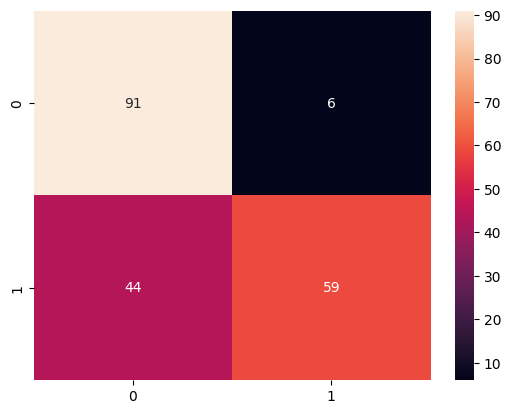

In [49]:
import seaborn as sns
sns.heatmap(confusion_matrix(y_test,rfy_pred),annot=True)

In [50]:
accuracy_score(y_test,rfy_pred)

0.75